## Learning Notebook: From Logistic Regression to Neural Networks (CIFAR-10)

### Overview

This notebook is both an **exercise and a learning resource**. It will guide you through applying **logistic regression** and a **basic neural network** to the **CIFAR-10 image classification dataset**. You'll explore how neural networks build on classical techniques and why they perform better on complex data like images.

### Context

This notebook highlights the most important steps to build a very simple fully conntected Neural Network with couple of layers. You will have to prepare the data for the model, apply the right loss function, and the right optimizer. 

### Goal:
Solve all tasks marked as "" ✅ Task for students""
- Train a logistic regression classifier on CIFAR-10 using flattened image vectors
- Train a neural network with at least one hidden layer and compare its performance
- Experiment with different learning rates and compare the results
- Visualize and interpret confusion matrices and train/test loss curves
- (Optional) Experiment with different hidden layer sizes and observe how accuracy changes
- (Optional) Add a second hidden layer and evaluate the impact
- (Optional) try to add learning rate decay and dropout

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [4]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

### Read and process the data

In [5]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

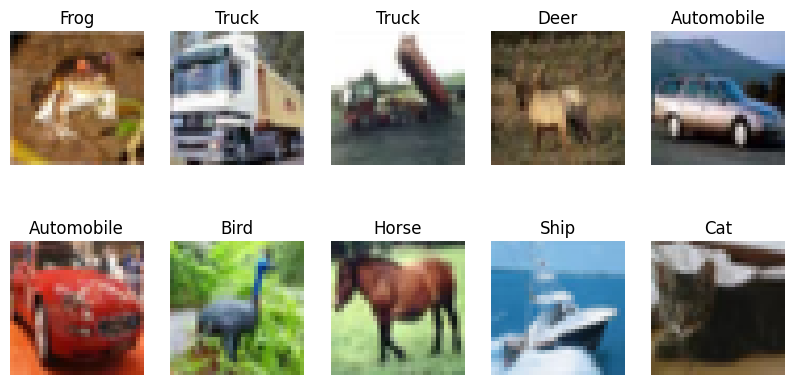

In [6]:
# Visualize Some input images with their classes
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [7]:
# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [8]:
# Flatten the input
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [9]:
# One-hot encoding needed for the softmax function of the neural network
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

### Build and train a logistic regression model

building a Logistic Regression using sklearn functions, train for 100 iterations.

In [10]:
# Subsample for logistic regression
n_samples = 3000  # or 5000 for faster results
X_train_flat_sub = X_train_flat[:n_samples]
y_train_sub = y_train[:n_samples]


# code the logistic regression model and train it for 100 iterations, and try different solvers (at least two)
logreg = LogisticRegression(max_iter=100, solver='saga', verbose=1)
logreg.fit(X_train_flat_sub, y_train_sub)

max_iter reached after 35 seconds


c:\Users\Nutzer\Documents\programming scripts\uni\semester4\ai\ex6_neural_networks\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

printing the classification report on the complete test data and on the complete train data. Are the results better than random classifier?

In [11]:
y_train_pred_log = logreg.predict(X_train_flat)
y_test_pred_log = logreg.predict(X_test_flat)

print(
    "Train data repot:\n", classification_report(y_train, y_train_pred_log)
)

print(
    "Test data repot:\n", classification_report(y_test, y_test_pred_log)
)

Train data repot:
               precision    recall  f1-score   support

           0       0.39      0.41      0.40      5000
           1       0.45      0.41      0.42      5000
           2       0.29      0.29      0.29      5000
           3       0.26      0.24      0.25      5000
           4       0.30      0.32      0.31      5000
           5       0.27      0.25      0.26      5000
           6       0.39      0.39      0.39      5000
           7       0.41      0.38      0.40      5000
           8       0.44      0.50      0.47      5000
           9       0.42      0.42      0.42      5000

    accuracy                           0.36     50000
   macro avg       0.36      0.36      0.36     50000
weighted avg       0.36      0.36      0.36     50000

Test data repot:
               precision    recall  f1-score   support

           0       0.37      0.38      0.38      1000
           1       0.45      0.40      0.43      1000
           2       0.26      0.27      0.

The Confusion Matrices for the logistic regression 

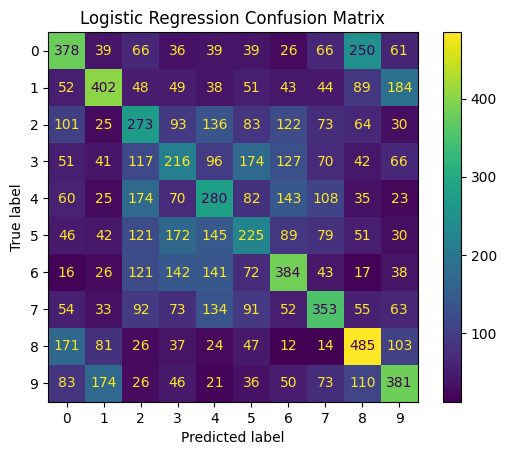

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_log)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Now Build and train a Neural Network

The model can contain several hidden layers, and as it generates **multinomial classifications** of the input images, we need to apply the **softmax function** to the output logits. 


#### Neural Network Architecture Summary

Build  a **simple feedforward neural network** for image classification on CIFAR-10. Add the following layers:

1. **Input Layer (Flatten)**

   * Converts each input image from shape **(32, 32, 3)** into a **1D vector of size 3072** (32 × 32 × 3).
   * This prepares the image data for fully connected layers.

2. **Hidden Layer (Dense)**

   * A fully connected layer with **128 neurons**.
   * Uses the **ReLU** activation function to introduce non-linearity.

3. **Output Layer (Dense)**

   * A fully connected layer with **10 neurons**, one for each class in CIFAR-10.
   * Uses **softmax** activation to output a probability distribution over the 10 classes.
---

#### What is the Softmax Function?

The **softmax function** is a normalized exponential function that maps a vector of continuous values (logits) into a vector of probabilities, ensuring that:
- All probabilities are non-negative.
- The sum of the probabilities equals 1.

#### Softmax Equation
The softmax function is defined as:

$$\sigma(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{N} e^{z_j}}$$

Where:
- \( $z_i$): Logit (input to the softmax function) for class (i).
- \( $N$): Total number of classes.
- \( $e^{z_i}$): Exponential of the logit for class (i).
- \( $\sigma(z_i)$): Probability for class (i).


#### Example Input and Output

Let’s consider a vector of logits \( z \) for a 10-class problem:


$$z = [2.0, 1.0, 0.1, -1.0, 0.5, -0.2, 1.5, -0.5, 0.3, -1.5]$$

Using the softmax function, we calculate the probabilities:

1. Compute ($e^{z_i}$) for each ( $z_i$):

   $$e^z = [7.39, 2.72, 1.11, 0.37, 1.65, 0.82, 4.48, 0.61, 1.35, 0.22]$$


2. Compute the sum of all exponentials:

   $$\text{Sum} = 20.72$$

3. Normalize each exponential by dividing by the sum:

   $$\sigma(z) = \frac{e^z}{\text{Sum}} = [0.356, 0.131, 0.054, 0.018, 0.080, 0.039, 0.216, 0.030, 0.065, 0.011]$$

#### Final Probabilities
The output probabilities are:

$$[0.356, 0.131, 0.054, 0.018, 0.080, 0.039, 0.216, 0.030, 0.065, 0.011]$$

These probabilities sum up to 1 and can be interpreted as the likelihood of the input belonging to each class.

--- 

#### Use in Classification
The class with the highest probability (e.g., $\text{argmax}(\sigma(z))$) is the predicted class.


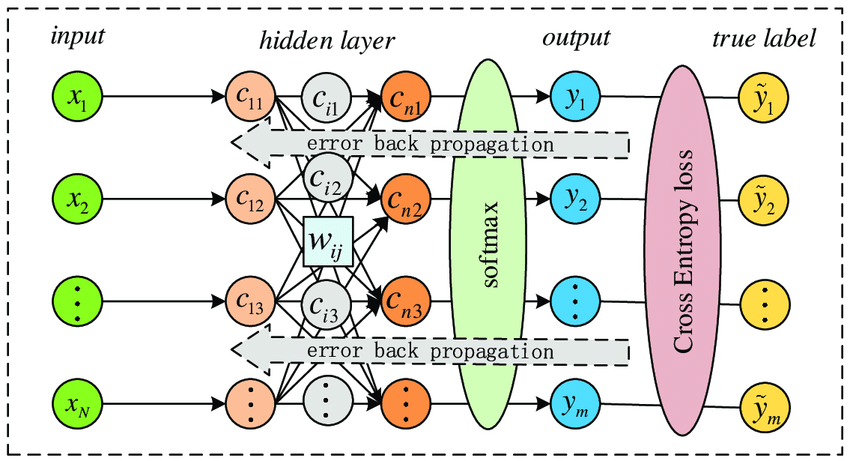

Zhou, Yangfan & Zhang, Mingchuan & Zhu, Junlong & Zheng, Ruijuan & Wu, Qingtao. (2019). MPCE: A Maximum Probability Based Cross Entropy Loss Function for Neural Network Classification. IEEE Access. PP. 1-1. 10.1109/ACCESS.2019.2946264. 

✅ Task for students: read the instructions above and code the mdoel using keras functions

In [13]:

#Input layer step (flatten)
print(f"X shape: {X_train_flat.shape}")
print(f"Y shape: {y_train_cat.shape}")

#2. step: hidden layer (dense)


model = Sequential()
model.add(Dense(512, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_flat, y_train_cat, epochs=7, batch_size=64, validation_data=(X_test_flat, y_test_cat))
# Evaluate the model



X shape: (50000, 3072)
Y shape: (50000, 10)
Epoch 1/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.3208 - loss: 1.8743 - val_accuracy: 0.3685 - val_loss: 1.7552
Epoch 2/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3977 - loss: 1.6791 - val_accuracy: 0.4246 - val_loss: 1.6159
Epoch 3/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4335 - loss: 1.5850 - val_accuracy: 0.4500 - val_loss: 1.5602
Epoch 4/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4570 - loss: 1.5213 - val_accuracy: 0.4408 - val_loss: 1.5727
Epoch 5/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4694 - loss: 1.4840 - val_accuracy: 0.4659 - val_loss: 1.4895
Epoch 6/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4824 - loss: 1.4464 - val_accuracy: 0.4848 - val_loss: 1.4562
Epoch 7/7
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4973 - loss: 1.4095 - val_accuracy: 0.4823 - val_loss: 1.4459


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4823 - loss: 1.4459
loss=1.4458985328674316
acc=0.4823000133037567
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Test data repot:
               precision    recall  f1-score   support

           0       0.56      0.53      0.54      1000
           1       0.65      0.56      0.61      1000
           2       0.41      0.29      0.34      1000
           3       0.30      0.36      0.33      1000
           4       0.44      0.36      0.40      1000
           5       0.34      0.47      0.39      1000
           6       0.53      0.43      0.48      1000
           7       0.60      0.52      0.55      1000
           8       0.52      0.73      0.61      1000
           9       0.58      0.57      0.58      1000

    accuracy                           0.48     10000
   macro avg       0.49      0.48      0.48     10000
weighted avg       0.49      0.48      0.48     10000



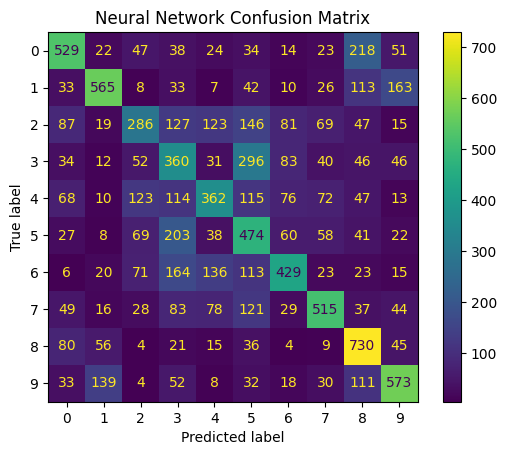

In [14]:
loss, acc = model.evaluate(X_test_flat, y_test_cat)

print(f"{loss=}")
print(f"{acc=}")


y_test_pred_nn = model.predict(X_test_flat)
y_test_pred_classes = np.argmax(y_test_pred_nn, axis=1)
print(
    "Test data repot:\n", classification_report(y_test, y_test_pred_classes)
)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_classes)
plt.title("Neural Network Confusion Matrix")
plt.show()



### Define the cost Function for Multinomial Classification in CIFAR-10


#### **Why Use `CategoricalCrossentropy`?**
   - CIFAR-10 is a dataset consisting of images belonging to **10 distinct classes**. For such problems, a multinomial (or multi-class) classification approach is required.
   - `CategoricalCrossentropy` is the standard loss function for measuring the difference between the predicted probability distribution over classes and the true class labels (one-hot encoded).

#### **Mathematical Explanation**
The `CategoricalCrossentropy` loss is calculated as:


$$ \text{Loss} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{C} y_{i,j} \cdot \log(\hat{y}_{i,j}) $$

Where:
- (N): Number of examples in the batch.
- (C): Number of classes (10 for CIFAR-10).
- ($y_{i,j}$): True label for class \(j\) (one-hot encoded: 1 for the correct class, 0 otherwise).
- \($\hat{y}_{i,j}$): Predicted probability for class (j).

This formula penalizes the model more heavily when it assigns low probability to the correct class.

### Define the optimizer we want to use to find the model parameters during the training

#### **What is `SGD`?**

Stochastic Gradient Descent is a faster, more scalable version of standard Gradient Descent optimizer.  Instead of computing gradients on the entire dataset (as in GD), SGD updates model weights using just one training example (or a small batch) at a time.

#### **Why use it?**
- Faster updates → learns faster in early training

- Adds noise → helps escape local minima and explore better solutions

- Scales well to large datasets where full-batch GD is too slow

✅ Task for students: read the instructions above and add an SGD optimizer with 0.01 learning rate and a loss function for your NN model

In [15]:
# Task for students: read the instructions above and add an SGD optimizer with 0.01 learning rate and a loss function for your NN model

from tensorflow.keras.optimizers import SGD # type: ignore

model.compile(optimizer=SGD(learning_rate = 0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Evaluate the model


✅ Task for students: train the model for 50 epochs and plot how the test and train loss change during the training

In [21]:
history_sgd = model.fit(X_train_flat, y_train_cat, epochs=50, batch_size=64, validation_data=(X_test_flat, y_test_cat))



Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5438 - loss: 1.2780 - val_accuracy: 0.4971 - val_loss: 1.4114
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5472 - loss: 1.2709 - val_accuracy: 0.5108 - val_loss: 1.3845
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5492 - loss: 1.2635 - val_accuracy: 0.5068 - val_loss: 1.3884
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5514 - loss: 1.2575 - val_accuracy: 0.5120 - val_loss: 1.3822
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5551 - loss: 1.2516 - val_accuracy: 0.5117 - val_loss: 1.3813
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5563 - loss: 1.2463 - val_accuracy: 0.5141 - val_loss: 1.3784
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5575 - loss: 1.2405 - val_accuracy: 0.5167 - val_loss: 1.3787
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5600 - loss: 1.2358 - val_accuracy: 0.

✅ Task for students: try different learning rates, 0.001, 0.01, 0.1 and explain what happened to the models train and test error. Write your observation below.

🔁 Remember: You must rebuild and recompile the model before training with each new learning rate. Reusing the same model can lead to misleading results.

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3146 - loss: 1.9170 - val_accuracy: 0.2232 - val_loss: 2.0953
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3840 - loss: 1.7330 - val_accuracy: 0.3875 - val_loss: 1.7099
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4138 - loss: 1.6547 - val_accuracy: 0.3350 - val_loss: 1.8422
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4338 - loss: 1.5990 - val_accuracy: 0.4184 - val_loss: 1.6173
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4502 - loss: 1.5549 - val_accuracy: 0.3591 - val_loss: 1.7828
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4609 - loss: 1.5152 - val_accuracy: 0.4060 - val_loss: 1.6393
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4765 - loss: 1.4791 - val_accuracy: 0.4173 - val_loss: 1.6187
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4877 - loss: 1.4483 - val_accuracy: 0.

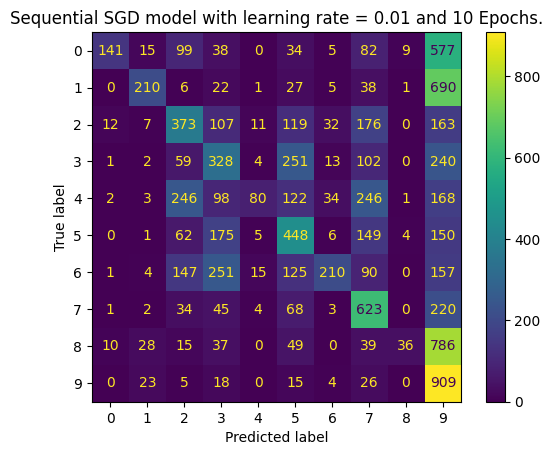

[[141  15  99  38   0  34   5  82   9 577]
 [  0 210   6  22   1  27   5  38   1 690]
 [ 12   7 373 107  11 119  32 176   0 163]
 [  1   2  59 328   4 251  13 102   0 240]
 [  2   3 246  98  80 122  34 246   1 168]
 [  0   1  62 175   5 448   6 149   4 150]
 [  1   4 147 251  15 125 210  90   0 157]
 [  1   2  34  45   4  68   3 623   0 220]
 [ 10  28  15  37   0  49   0  39  36 786]
 [  0  23   5  18   0  15   4  26   0 909]]


In [ ]:
# wir wolln ja noch fertig werden nh
EPOCHS = 10

def seq_model(lr:float, epochs: int = 10):
    model = Sequential()
    model.add(Dense(512, activation='relu'))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer=SGD(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train_flat, y_train_cat, epochs=epochs, batch_size=64, validation_data=(X_test_flat, y_test_cat))

    loss, acc = model.evaluate(X_test_flat, y_test_cat)

    print(f"{loss=}")
    print(f"{acc=}")

    y_test_pred_nn = model.predict(X_test_flat)
    y_test_pred_classes = np.argmax(y_test_pred_nn, axis=1)
    print(
        "Test data repot:\n", classification_report(y_test, y_test_pred_classes)
    )
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_classes)
    plt.title(f"Sequential SGD model with learning rate = {lr} and {epochs} Epochs.")
    plt.show()

    return confusion_matrix(y_test, y_test_pred_classes), model

mat, model = seq_model(.01, 10)

print(mat)


answer = """
your answer here
"""